In [1]:
import pickle
from pathlib import Path

import bicm
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score
from matplotlib import pyplot as plt, transforms

BASE = Path("/") / "scratch" / "SCRATCH_SAS" / "roman"

split_to_name = {
    "ESP": "ESP",
    "ESPC2": "$\\text{ESP}_\\text{S2}$",
    "I1e": "$\\text{I1}_\\text{L}$",
    "I1f": "$\\text{I1}_\\text{P}$",
    "C1e": "$\\text{S1}_\\text{L}$",
    "C1f": "$\\text{S1}_\\text{P}$",
    "C2": "S2",
}

def set_subplot_label(ax: plt.Axes, fig: plt.Figure, label: str) -> None:
    """
    Set the label for a subplot.
    Args:
        ax: The subplot
        fig: The figure
        label: The label to set
    """
    ax.text(
        0.0,
        1.0,
        label,
        transform=ax.transAxes + transforms.ScaledTranslation(
            -25 / 72,
            10 / 72,
            fig.dpi_scale_trans
        ),
        fontsize="x-large",
        va="bottom",
        fontfamily="serif",
    )

# Visualize Leakage

In [2]:
df = pd.read_csv("/home/rjo21/Downloads/ESP_performances.csv")
df.head()

,Metric,Model,ESP,ESPS2,I1P,S1P,I1L,S1L,S2
0,Accuracy / Macro F1,Non-interact. Baseline,0.738,0.739,0.735,0.737,0.698,0.735,0.733
1,Accuracy / Macro F1,Configuration Model,0.743,0.739,0.740,0.737,0.699,0.735,0.733
2,Accuracy / Macro F1,ESP,0.887,0.879,0.902,0.865,0.566,0.407,0.545
3,Accuracy / Macro F1,ProSmith,0.923,0.871,0.930,0.865,0.754,0.633,0.581
4,Accuracy / Macro F1,FusionESP,0.933,0.916,0.943,0.889,0.76,0.722,0.728


In [3]:
df["Metric"].unique()

array(['Accuracy / Macro F1',
       'Area Under the Receiver Operating Characteristic Curve (AUROC)',
       'Matthews Correlation Coefficient (MCC)'], dtype=object)

In [4]:
leak = pd.read_csv("/home/rjo21/Downloads/ESP_leakages.csv")
leak.head()

,Leakage Source,Type,ESP,ESPS2,I1P,S1P,I1L,S1L,S2
0,Train-Val,MSL,0.142,0.141,0.141,0.144,0.128,0.062,0.023
1,Train-Val,PSL,0.052,0.056,0.053,0.022,0.070,0.058,0.009
2,Train-Val,TSL,0.194,0.197,0.194,0.166,0.198,0.120,0.032
3,Train-Test,MSL,0.284,0.285,0.284,0.278,0.249,0.136,0.067
4,Train-Test,PSL,0.100,0.112,0.133,0.044,0.089,0.112,0.015


In [5]:
sum_leak = leak[["Type", "ESP", "ESPS2", "I1P", "S1P", "I1L", "S1L", "S2"]].groupby("Type").agg("mean").reset_index()
sum_leak

,Type,ESP,ESPS2,I1P,S1P,I1L,S1L,S2
0,MSL,0.156000,0.156,0.155667,0.154333,0.135333,0.072000,0.031333
1,PSL,0.055667,0.061,0.071333,0.024333,0.058333,0.060667,0.008667
2,TSL,0.211667,0.217,0.227000,0.178667,0.193667,0.132667,0.040000


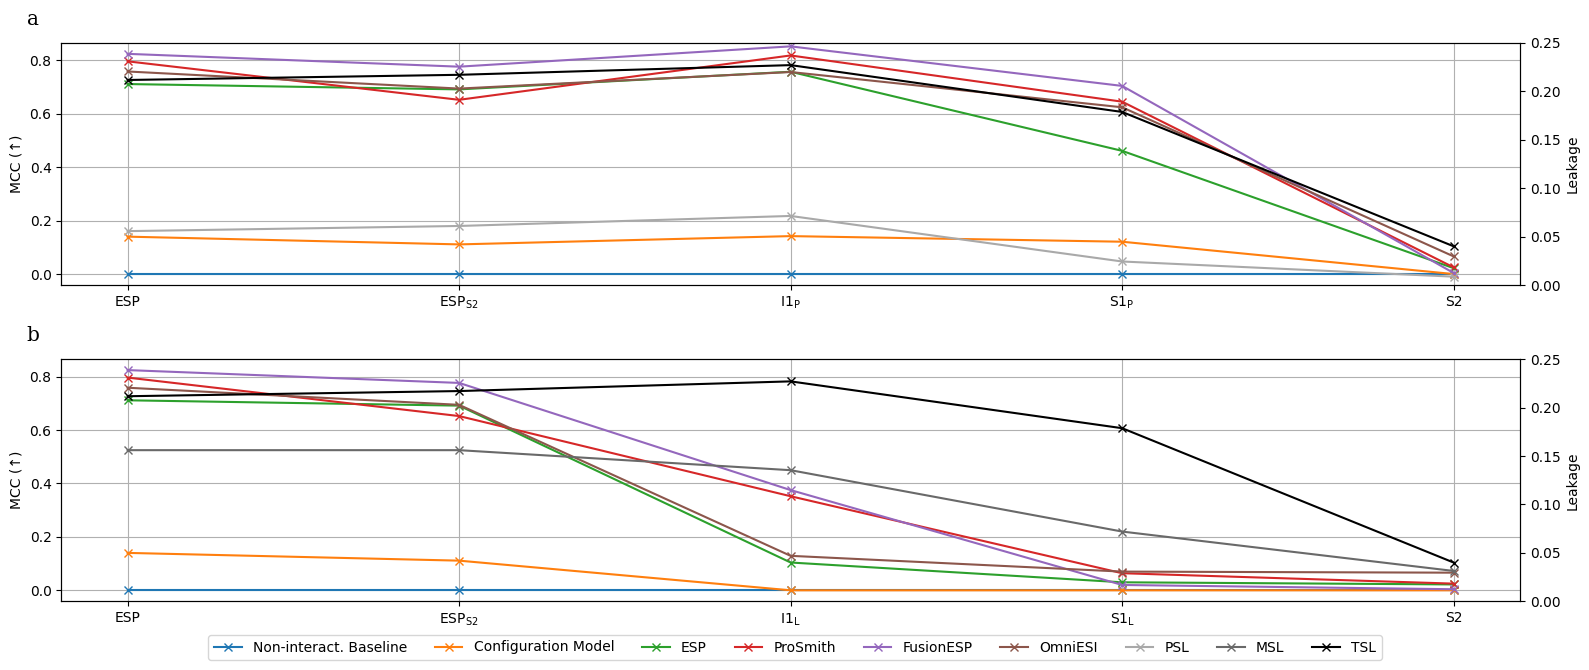

In [6]:
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 1)
axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]
metric = "Matthews Correlation Coefficient (MCC)"
m_name = "MCC"

for model in df["Model"].unique():
    axs[0].plot(
        df[(df["Model"] == model) & (df["Metric"] == metric)][["ESP", "ESPS2", "I1P", "S1P", "S2"]].values.flatten(), label=model, marker="x",
    )
    axs[1].plot(
        df[(df["Model"] == model) & (df["Metric"] == metric)][["ESP", "ESPS2", "I1L", "S1L", "S2"]].values.flatten(), marker="x",
    )

laxs = [axs[0].twinx(), axs[1].twinx()]
laxs[0].plot(
    sum_leak[(sum_leak["Type"] == "PSL")][["ESP", "ESPS2", "I1P", "S1P", "S2"]].values.flatten(), label="PSL", color="darkgray", marker="x",
)
laxs[1].plot(
    sum_leak[(sum_leak["Type"] == "MSL")][["ESP", "ESPS2", "I1L", "S1L", "S2"]].values.flatten(), label="MSL", color="dimgray", marker="x",
)

axs[0].set_xticks(range(5), [split_to_name[s] for s in ["ESP", "ESPC2", "I1f", "C1f", "C2"]])
axs[1].set_xticks(range(5), [split_to_name[s] for s in ["ESP", "ESPC2", "I1e", "C1e", "C2"]])
axs[0].sharey(axs[1])
for i in range(2):
    axs[i].grid()
    axs[i].set_ylabel(m_name + " (↑)")
    laxs[i].plot(
        sum_leak[(sum_leak["Type"] == "TSL")][["ESP", "ESPS2", "I1P", "S1P", "S2"]].values.flatten(), label="TSL", color="black", marker="x",
    )
    laxs[i].set_ylim(0.0, 0.25)
    laxs[i].set_ylabel("Leakage")

handles, labels = axs[0].get_legend_handles_labels()

msl_handles, mls_labels = laxs[0].get_legend_handles_labels()
handles.append(msl_handles[0])
labels.append(mls_labels[0])

psl_handles, psl_labels = laxs[1].get_legend_handles_labels()
handles += psl_handles
labels += psl_labels

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.04), bbox_transform=fig.transFigure, ncol=9)  # -0.08
set_subplot_label(axs[0], fig, "a")
set_subplot_label(axs[1], fig, "b")

plt.tight_layout(rect=[0, 0.075, 1, 1])
plt.savefig("Fig2_perf_leaks.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [17]:
np.corrcoef(
    [0.057, 0.057, 0.070, 0.048, 0.045, 0.030, 0.006],
    [0.944, 0.932, 0.946, 0.876, 0.587, 0.561, 0.545]
)[0, 1]

0.840485206987971

# Configuration model

In [63]:
def fit_config_model(split: str):
    with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/train_{split}_3S.pkl", "rb") as f:
        df = pickle.load(f)
    
    lig = list(df["molecule ID"].unique())
    tar = list(df["Uniprot ID"].unique())

    lig2idx = {l: i for i, l in enumerate(lig)}
    tar2idx = {t: i for i, t in enumerate(tar)}

    A_pos = np.zeros((len(lig), len(tar)), dtype=np.float32)
    A_neg = np.zeros((len(lig), len(tar)), dtype=np.float32)

    for _, row in df.iterrows():
        i, j = lig2idx[row["molecule ID"]], tar2idx[row["Uniprot ID"]]
        if row["Binding"] == 1:
            A_pos[i, j] = 1
        else:
            A_neg[i, j] = 1
    
    graph_pos = bicm.BipartiteGraph(A_pos)
    graph_pos.solve_tool()
    P_pos = graph_pos.get_bicm_matrix()

    graph_neg = bicm.BipartiteGraph(A_neg)
    graph_neg.solve_tool()
    P_neg = graph_neg.get_bicm_matrix()

    P_cond = P_pos / (P_pos + P_neg)

    rho_lig = A_pos.sum(axis=1) / (A_pos.sum(axis=1) + A_neg.sum(axis=1))
    rho_tar = A_pos.sum(axis=0) / (A_pos.sum(axis=0) + A_neg.sum(axis=0))
    
    P_ind = A_pos.sum() / (A_pos.sum() + A_neg.sum())

    return P_cond, rho_lig, rho_tar, P_ind, lig2idx, tar2idx


def eval_config_model_cond(df, P_cond, lig2idx, tar2idx):
    ys = []
    y_hats = []

    for _, row in df.iterrows():
        l = row["molecule ID"]
        t = row["Uniprot ID"]
        if l not in lig2idx or t not in tar2idx:
            continue
        ys.append(row["Binding"])
        y_hats.append(P_cond[lig2idx[l], tar2idx[t]])
    
    return ys, y_hats


def eval_config_model_semi(df, rho_lig, rho_tar, lig2idx, tar2idx):
    ys = []
    y_hats = []

    for _, row in df.iterrows():
        l = row["molecule ID"]
        t = row["Uniprot ID"]
        if (l not in lig2idx) == (t not in tar2idx):
            continue

        ys.append(row["Binding"])
        if l in lig2idx:
            y_hats.append(rho_lig[lig2idx[l]])
        else:
            y_hats.append(rho_tar[tar2idx[t]])
    return ys, y_hats


def eval_config_model_ind(df, P_ind):
    ys = df["Binding"].tolist()
    y_hats = [P_ind] * len(ys)
    return ys, y_hats


def eval_all_neg_baseline(df):
    ys = df["Binding"].tolist()
    y_hats = [0] * len(ys)
    return ys, y_hats

In [68]:
outputs = []
all_neg_outputs = []

for split in ["ESP", "ESPC2", "I1f", "C1f", "I1e", "C1e", "C2"]:
    print(f"Evaluating split {split}...")
    with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/test_{split}_3S.pkl", "rb") as f:
        df = pickle.load(f)

    P_cond, rho_lig, rho_tar, P_ind, lig2idx, tar2idx = fit_config_model(split)
    if split == "C2":
        outputs.append(eval_config_model_ind(df, P_ind))
    else:
        outputs.append(eval_config_model_semi(df, rho_lig, rho_tar, lig2idx, tar2idx))
    all_neg_outputs.append(eval_all_neg_baseline(df))

Evaluating split ESP...


/home/rjo21/miniconda3/envs/smtbnn/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 2.356473487452604e-07
max columns error = 1.851088171633819e-10
total error = 8.94386728456098e-07
Solver converged.
max rows error = 6.821210263296962e-13
max columns error = 1.5418777365994174e-12
total error = 3.525755243316553e-10
Solver converged.
Evaluating split ESPC2...


/home/rjo21/miniconda3/envs/smtbnn/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 2.2737367544323206e-13
max columns error = 7.283063041541027e-14
total error = 4.6571191347766216e-11
Solver converged.
max rows error = 1.1368683772161603e-13
max columns error = 2.5224267119483557e-13
total error = 1.42943878955748e-10
Solver converged.
Evaluating split I1f...


...

/home/rjo21/miniconda3/envs/smtbnn/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 5.075125955045223e-07
max columns error = 8.119904748582485e-11
total error = 1.0208919929421967e-06
Solver converged.
max rows error = 9.761768296812079e-06
max columns error = 6.746965929949056e-06
total error = 5.12952677320655e-05
Solver converged.
Evaluating split C1e...


/home/rjo21/miniconda3/envs/smtbnn/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 1.1106071724498179e-06
max columns error = 5.08866371262684e-09
total error = 4.377925975074248e-06
Solver converged.
max rows error = 2.6338174393458758e-05
max columns error = 5.275025607431871e-06
total error = 0.00012656958057366552
Solver converged.
Evaluating split C2...
max rows error = 1.1368683772161603e-13
max columns error = 9.592326932761353e-14
total error = 1.677169514380239e-11
Solver converged.
max rows error = 9.825577535593766e-06
max columns error = 2.3951472414296404e-06
total error = 5.391386053865688e-05
Solver converged.


/home/rjo21/miniconda3/envs/smtbnn/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


In [71]:
for split, (ys, y_hats) in zip(["ESP", "ESPC2", "I1f", "C1f", "I1e", "C1e", "C2"], all_neg_outputs):
    print(f"Split {split}:")
    print(f"  ACC: {accuracy_score(ys, np.round(y_hats)):.3f}")
    print(f"  AUC: {roc_auc_score(ys, y_hats):.3f}")
    print(f"  MCC: {matthews_corrcoef(ys, np.round(y_hats)):.3f}")

for split, (ys, y_hats) in zip(["ESP", "ESPC2", "I1f", "C1f", "I1e", "C1e", "C2"], outputs):
    print(f"Split {split}:")
    print(f"  ACC: {accuracy_score(ys, np.round(y_hats)):.3f}")
    print(f"  AUC: {roc_auc_score(ys, y_hats):.3f}")
    print(f"  MCC: {matthews_corrcoef(ys, np.round(y_hats)):.3f}")

Split ESP:
  ACC: 0.738
  AUC: 0.500
  MCC: 0.000
Split ESPC2:
  ACC: 0.739
  AUC: 0.500
  MCC: 0.000
Split I1f:
  ACC: 0.735
  AUC: 0.500
  MCC: 0.000
Split C1f:
  ACC: 0.737
  AUC: 0.500
  MCC: 0.000
Split I1e:
  ACC: 0.698
  AUC: 0.500
  MCC: 0.000
Split C1e:
  ACC: 0.735
  AUC: 0.500
  MCC: 0.000
Split C2:
  ACC: 0.733
  AUC: 0.500
  MCC: 0.000
Split ESP:
  ACC: 0.743
  AUC: 0.574
  MCC: 0.140
Split ESPC2:
  ACC: 0.739
  AUC: 0.583
  MCC: 0.111
Split I1f:
  ACC: 0.740
  AUC: 0.590
  MCC: 0.142
Split C1f:
  ACC: 0.737
  AUC: 0.574
  MCC: 0.121
Split I1e:
  ACC: 0.699
  AUC: 0.501
  MCC: 0.000
Split C1e:
  ACC: 0.735
  AUC: 0.499
  MCC: 0.000
Split C2:
  ACC: 0.733
  AUC: 0.500
  MCC: 0.000


# Uniqueness and Label ratios

In [2]:
with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/train_ESP_3S.pkl", "rb") as f:
    train_df = pickle.load(f)
with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/val_ESP_3S.pkl", "rb") as f:
    val_df = pickle.load(f)
with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/test_ESP_3S.pkl", "rb") as f:
    test_df = pickle.load(f)

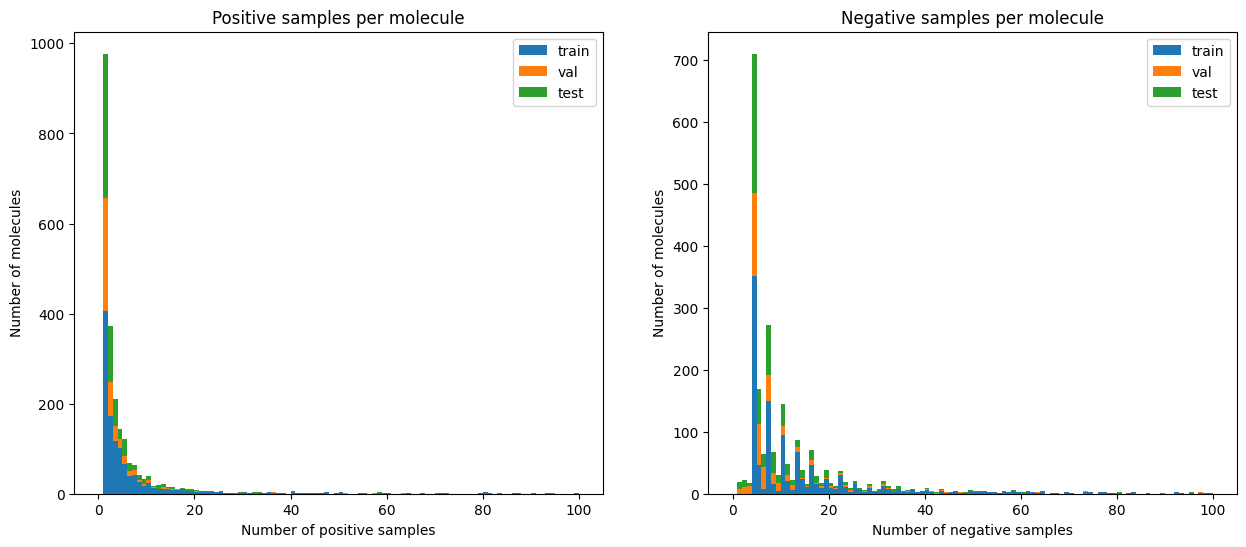

In [15]:
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 2)
axs = [
    fig.add_subplot(gs[0]), fig.add_subplot(gs[1]),
]
axs[0].hist([
    train_df[train_df["Binding"] == 1].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
    val_df[val_df["Binding"] == 1].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
    test_df[test_df["Binding"] == 1].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
], bins=100, stacked=True, label=["train", "val", "test"], range=(0, 100))
axs[1].hist([
    train_df[train_df["Binding"] == 0].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
    val_df[val_df["Binding"] == 0].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
    test_df[test_df["Binding"] == 0].groupby("molecule ID").agg({"Binding": lambda x: len(x)}).reset_index()["Binding"],
], bins=100, stacked=True, label=["train", "val", "test"], range=(0, 100))
axs[0].set_title("Positive samples per molecule")
axs[1].set_title("Negative samples per molecule")
axs[0].set_xlabel("Number of positive samples")
axs[1].set_xlabel("Number of negative samples")
axs[0].set_ylabel("Number of molecules")
axs[1].set_ylabel("Number of molecules")
axs[0].legend()
axs[1].legend()
plt.show()

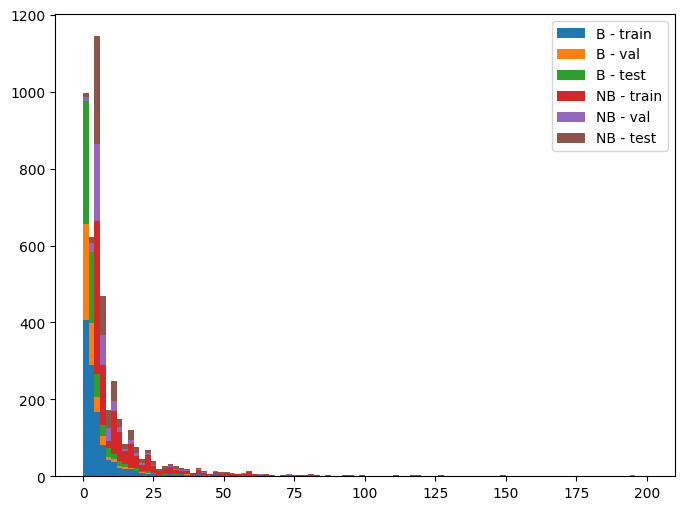

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.legend()
plt.show()

In [ ]:

val_df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"]
test_df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"]

In [4]:
ESP = Path("/") / "scratch" / "SCRATCH_SAS" / "roman" / "OmniESI"

In [ ]:
for split in ["I1e", "C1e", "I1f", "C1f", "ESP", "ESPC2", "C2"]:
    (ESP / "ESP" / split).mkdir(exist_ok=True, parents=True)
    for fold in ["train", "val", "test"]:
        with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/{fold}_{split}_3S.pkl", "rb") as f:
            data = pickle.load(f)
        print(f"{fold}_{split}_3S.pkl:")
        print(f"  - Total samples   : {len(data)}")
        print(f"  - Unique proteins : {len(data['Uniprot ID'].unique())}")
        print(f"  - Unique molecules: {len(data['molecule ID'].unique())}")
        x = data.groupby("Uniprot ID").agg({"Binding": "mean"}).reset_index()["Binding"]
        print(f"  - Binding mean    : {x.mean():.3f}")
        print(f"  - {len(data)} & {len(data['Uniprot ID'].unique())} & {len(data['molecule ID'].unique())} & {x.mean():.3f}")
        # if split != "ESP":
        #     data.rename(columns={"Sequence": "Protein", "Binding": "Y"}, inplace=True)
        #     data["id"] = list(range(len(data)))
        #     data[["Protein", "SMILES", "Y", "id"]].to_csv(ESP / "ESP" / split / f"{fold}.csv", index=False)

train_I1e_3S.pkl:
  - Total samples   : 48938
  - Unique proteins : 8986
  - Unique molecules: 940
  - Binding mean    : 0.265
  - 48938 & 8986 & 940 & 0.265
val_I1e_3S.pkl:
  - Total samples   : 6966
  - Unique proteins : 1709
  - Unique molecules: 159
  - Binding mean    : 0.266
  - 6966 & 1709 & 159 & 0.266
test_I1e_3S.pkl:
  - Total samples   : 12121
  - Unique proteins : 3495
  - Unique molecules: 255
  - Binding mean    : 0.365
  - 12121 & 3495 & 255 & 0.365
train_C1e_3S.pkl:
  - Total samples   : 48489
  - Unique proteins : 9558
  - Unique molecules: 871
  - Binding mean    : 0.267
  - 48489 & 9558 & 871 & 0.267
val_C1e_3S.pkl:
  - Total samples   : 6825
  - Unique proteins : 1611
  - Unique molecules: 152
  - Binding mean    : 0.273
  - 6825 & 1611 & 152 & 0.273
test_C1e_3S.pkl:
  - Total samples   : 13839
  - Unique proteins : 3139
  - Unique molecules: 331
  - Binding mean    : 0.268
  - 13839 & 3139 & 331 & 0.268
train_I1f_3S.pkl:
  - Total samples   : 48660
  - Unique prote

In [7]:
train = pd.read_csv(ESP / "ESP" / "ESP" / "train.csv")
val = pd.read_csv(ESP / "ESP" / "ESP" / "val.csv")
test = pd.read_csv(ESP / "ESP" / "ESP" / "test.csv")
df = pd.concat([train, val, test], axis=0)
prot_id_map = {k: int(v) for k, v in df[["Protein", "Protein_index"]].values}

In [ ]:
for split in ["ESP", "ESPC2", "I1f", "C1f", "I1e", "C1e", "C2"]:
    for fold in ["train", "val", "test"]:
        tmp = pd.read_csv(ESP / "ESP" / split / f"{fold}.csv")
        print(len(tmp))
        tmp["Protein_index"] = tmp["Protein"].map(prot_id_map)
        tmp = tmp[tmp["Protein_index"] == tmp["Protein_index"]]  # filter out rows with NaN Protein_index
        print(len(tmp))
        tmp["Protein_Path"] = tmp["Protein_index"].apply(lambda x: str(ESP / "ESP" / "esm" / f"{str(x).split(".")[0]}.pt"))
        print(x := len(list(filter(lambda x: x != x, tmp["Protein_index"].values))))
        print(len(list(filter(lambda x: x.endswith("nan.pt"), tmp["Protein_Path"].values))))
        tmp.to_csv(ESP / "ESP" / split / f"{fold}.csv", index=False)
        print(f"saved to", ESP / "ESP" / split / f"{fold}.csv")

48541
48541
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESP/train.csv
7008
7008
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESP/val.csv
14034
14034
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESP/test.csv
22128
22128
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESPC2/train.csv
3095
3095
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESPC2/val.csv
6344
6344
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/ESPC2/test.csv
48660
48628
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/I1f/train.csv
6982
6982
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/I1f/val.csv
13844
13844
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/I1f/test.csv
48497
48478
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/C1f/train.csv
6941
6925
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/C1f/val.csv
13919
13919
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/C1f/test.csv
48938
48912
0
0
saved to /scratch/SCRATCH_SAS/roman/OmniESI/ESP/I1e/train.csv
69

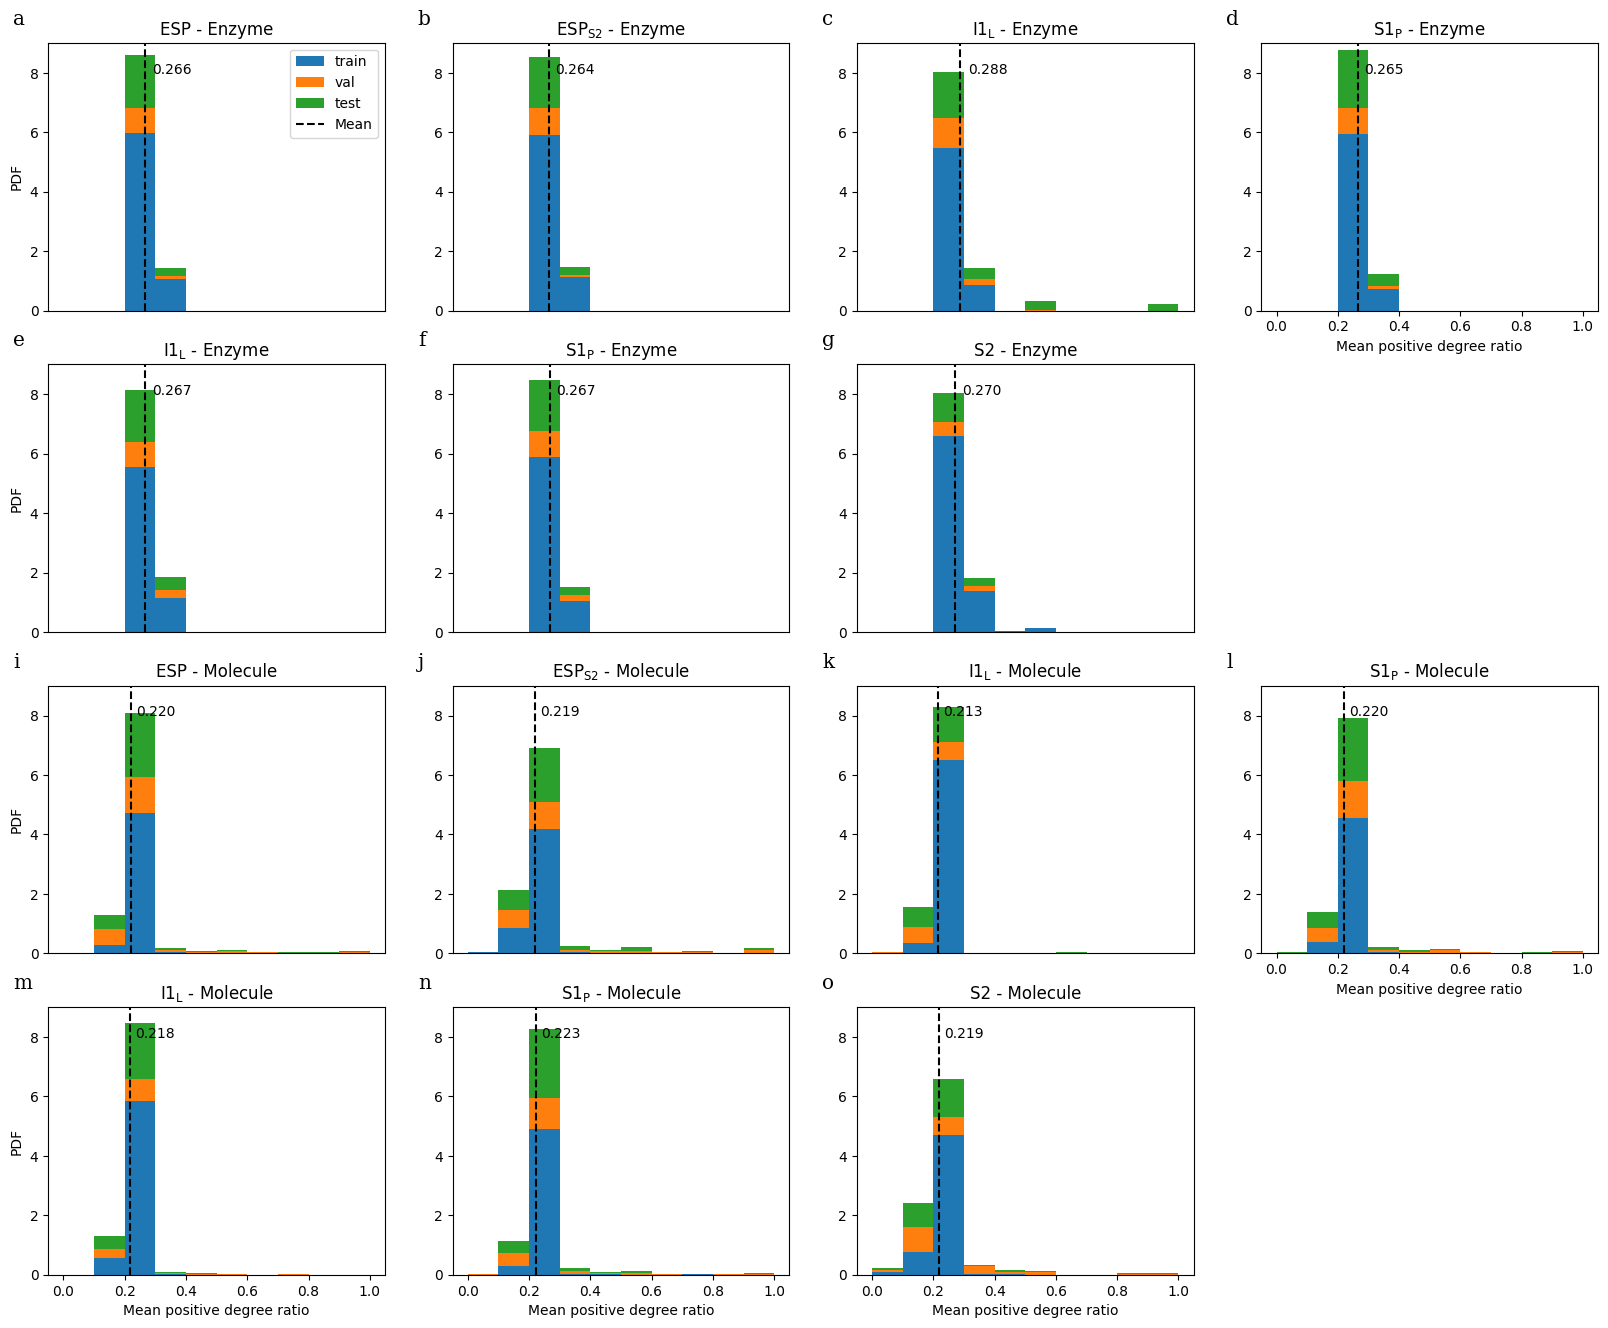

In [43]:
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4)
axs = [
    fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3]),
    fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3]),
    fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2]), fig.add_subplot(gs[2, 3]),
    fig.add_subplot(gs[3, 0]), fig.add_subplot(gs[3, 1]), fig.add_subplot(gs[3, 2]), fig.add_subplot(gs[3, 3]),
]

for i, split in enumerate(["ESP", "ESPC2", "I1e", "I1f", "C1e", "C1f", "C2"]):
    with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/train_{split}_3S.pkl", "rb") as f:
        train_df = pickle.load(f)
    with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/val_{split}_3S.pkl", "rb") as f:
        val_df = pickle.load(f)
    with open(f"/wibicomfs/STBS/roman/ESP/data/3splits/test_{split}_3S.pkl", "rb") as f:
        test_df = pickle.load(f)
    df = pd.concat([train_df, val_df, test_df], axis=0)
    axs[i].hist([
            train_df.groupby("Uniprot ID").agg({"Binding": "mean"}).reset_index()["Binding"],
            val_df.groupby("Uniprot ID").agg({"Binding": "mean"}).reset_index()["Binding"],
            test_df.groupby("Uniprot ID").agg({"Binding": "mean"}).reset_index()["Binding"]
        ], bins=10, label=["train", "val", "test"], range=(0, 1), stacked=True, density=True)
    axs[i].set_title(f"{split_to_name[split]} - Enzyme")
    axs[i].axvline(p_mean := df.groupby("Uniprot ID").agg({"Binding": "mean"}).reset_index()["Binding"].mean(), color="black", linestyle="--", label="Mean")
    axs[i].text(p_mean + 0.1, 0.9, f"{p_mean:.3f}", transform=axs[i].transAxes, ha="center", va="center")
    axs[i + 8].hist([
            train_df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"],
            val_df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"],
            test_df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"]
        ], bins=10, label=["train", "val", "test"], range=(0, 1), stacked=True, density=True)
    axs[i + 8].set_title(f"{split_to_name[split]} - Molecule")
    axs[i + 8].axvline(m_mean := df.groupby("molecule ID").agg({"Binding": "mean"}).reset_index()["Binding"].mean(), color="black", linestyle="--", label="Mean")
    axs[i + 8].text(m_mean + 0.1, 0.9, f"{m_mean:.3f}", transform=axs[i + 8].transAxes, ha="center", va="center")

axs[0].legend()
for i in range(0, 16):
    if i != 7 and i != 15:
        axs[i].sharey(axs[0])
        set_subplot_label(axs[i], fig, chr(ord("a") + i))
        if i in {0, 4, 8, 12}:
            axs[i].set_ylabel("PDF")
        # else:
        #     axs[i].set_yticks([])
        if i in {3, 11, 12, 13, 14}:
            axs[i].set_xlabel("Mean positive degree ratio")
        else:
            axs[i].set_xticks([])
    else:
        axs[i].set_axis_off()

plt.savefig("Fig4_label_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()